# Bispectrum and bicoherence

## Summary

Bicoherence is a squared, normalized version of the bispectrum. Bicoherence is real and normalized between 0 and 1. Bicoherence measure how much phase coupling / "locking" there is between signals. In the following, we consider auto-bispectrum and auto-bicoherence - i.e. the phase coupling between different frequency components in the same signal.

## Definitions

### Bispectrum

$B(f_1, f_2) = F(f_1) . F(f_2) . F^*(f_1+f_2)$  , with $f_1$ and $f_2$ the 2 frequencies considered, $B$ the bispectrum, $F$ the Fourier transform, $^*$ the complex conjugate.

A $F$ transform results in a complex vector. From standard complex calculations, the $B$ magnitude is the product of the $F$ magnitudes, and the $B$ phase is the sum of the $F$ phases (with a - for the $^*$ one).

## Bicoherence

The bicoherence is obtained by averaging over several bispectra, and normalizing. There are several ways to do the normalization. We will prefer the "absolute norm" normalization:

$b(f_1, f_2) = abs(sum_n(B_n(f_1, f_2)) / sum_n(abs(B_n(f_1, f_2)))$  , with $b$ the bicoherence, $B_n(f_1, f_2)$ the bicoherence spectrum on segment number $n$ at frequencies $f_1$ and $f_2$, $sum_n$ the sum over the $n$ segments.

### Interpretation

Considering a signal that is stationary in time:

- if the signal components at frequencies $f_1$, $f_2$, $f_3$, are not phase locked, then the phase of the $B_n(f_1, f_2)$ will be random, and the $sum_n(B_n(f_1, f_2)$ will average to $0$ at the limit; hence, the bicoherence will be $0$
- if the signal components at frequencies $f_1$, $f_2$, $f_3$ are phase locked, then the phase of the $B_n(f_1, f_2)$ will be constant, and the $abs(sum_n(B_n(f_1, f_2))$ will average to $n . abs(B_n(f_1, f_2))$; so does the denominator, so the bicoherence will be $1$.
- there are other ways to normalize and compute the bicoherence, which may make the signals stand out more - for example, using some variation of the square instead of the absolute norm. See the wiki link below.

So a bicoherence of $0$ indicates that the signals at $f_1$, $f_2$, $f_3$ are not phase locked / coupled, and a bicoherence of $1$ indicate that they are fully phase locked / coupled.

Note that this is a necessary, but not a sufficient, condition for frequency components to be coupled by a non-linear mechanism (like "correlation is not causation").

### Possible extensions

TODO: discuss:

- 2 different signals
- different sampling frequencies

## Sources

- https://en.wikipedia.org/wiki/Bicoherence

## Implementation

In [1]:
import numpy as np
import numpy.typing as npt

from scipy import fftpack

In [2]:
# A verbose, possibly slow, un-optimized implementation of real-signal bispectrum and bi-coherence.
# The goal is correctness and ease-of-reading, not speed!
# Still, we use FFTs in reasonable ways, and we do vectorized operations not loops! :)
# But we do not cache anything, including FFT coeffs when repeating the same FFT many times; we compute same coefficients possibly twice (symmetry not taken into account); etc.


def split_signal_into_segments(signal: npt.NDArray, segment_length: int, n_overlap: int, use_next_fftlength: bool =True) ->  npt.NDArray:
    """Split a signal into segments:
    Arguments:
        - signal: the signal to split, a 1d numpy array
        - segment_length: the (minimum if use_next_fftlength is True) segment length
        - overlap: the int number of overlap samples between 2 consecutive segments
        - use_next_fftlength: True if should use the next segment length that allows fast FFT, False to force the current segment length
    Returns:
        - array_of_signals: such that array_of_signals[0, :] is the first segment of length segment_length, etc"""

    assert isinstance(signal, np.ndarray)
    assert signal.ndim == 1
    assert isinstance(segment_length, int)
    assert isinstance(n_overlap, int)
    assert isinstance (use_next_fftlength, bool)
    
    if use_next_fftlength:
        segment_length = fftpack.next_fast_len(segment_length)

    start_segments = np.arange(0, len(signal)-segment_length, segment_length-n_overlap)
    nbr_segments = len(start_segments)
    array_of_signals = np.full([nbr_segments, segment_length], np.nan)

    for crrt_segment in range(nbr_segments):
        array_of_signals[crrt_segment, :] = signal[start_segments[crrt_segment]: start_segments[crrt_segment]+segment_length]
    
    return array_of_signals


array_of_signals = split_signal_into_segments(np.arange(0, 10, 1), segment_length=4, n_overlap=2, use_next_fftlength=True)
res = np.array(
    [[0., 1., 2., 3.],
     [2., 3., 4., 5.],
     [4., 5., 6., 7.]])
np.testing.assert_allclose(res, array_of_signals)
array_of_signals = split_signal_into_segments(np.arange(0, 12, 1), segment_length=7, n_overlap=5, use_next_fftlength=True)
res = np.array(
    [[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
     [ 3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]])
np.testing.assert_allclose(res, array_of_signals)


def find_first_greater_or_equal_index(value:float, array: npt.NDArray):
    """Find the index of the first element in the array that is greater than the specified value.
    Arguments:
        - array (numpy.ndarray): The array to search.
        - value (float): The value to compare against.
    Returns:
        - int: The index of the first element greater than the specified value, the last index."""

    bool_array = array > value
    if bool_array.any():
        argmax = np.argmax(bool_array)
        return argmax
    else:
        return len(array)-1


def get_f_range_index(f_range, frequencies: npt.NDArray):
    """Get the range of index in frequencies that cover f_range. We assume that frequencies is an array of rfft
    frequencies from rfftfreq. We always skip the 0-frequency and the last frequency.
    Arguments:
        - f_range: the range of frequencies to cover, either [f1, f2] with f1<f2 and both are floats, or None
        - frequencies: the array of frequencies from rfftfreq
    Returns:
        - (idx_min, idx_max): the range of indexes so that frequencies[idx_min:idx_max] cover f_range"""

    assert isinstance(frequencies, np.ndarray)
    assert frequencies.ndim == 1
    np.testing.assert_approx_equal(0.0, frequencies[0])
    
    if f_range is None:
        return (1, len(frequencies)-1)
    else:
        assert isinstance(f_range, list)
        assert len(f_range) == 2
        assert isinstance(f_range[0], float)
        assert isinstance(f_range[1], float)
        assert f_range[0] < f_range[1]
        idx_min = find_first_greater_or_equal_index(f_range[0], frequencies)
        if idx_min > 1:
            idx_min = idx_min - 1
        idx_min = max(1, idx_min)
        idx_max = find_first_greater_or_equal_index(f_range[1], frequencies)
        if idx_max < len(frequencies)-2:
            idx_max = idx_max + 1
        idx_max = min(idx_max, len(frequencies)-1)
        return (int(idx_min), int(idx_max))


assert get_f_range_index(None, np.array([0., 1., 2., 3., 4., 5.])) == (1, 5)
assert get_f_range_index([-1.0, 7.0], np.array([0., 1., 2., 3., 4., 5.])) == (1, 5)
assert get_f_range_index([2., 3.], np.array([0., 1., 2., 3., 4., 5.])) == (2, 4)

def compute_auto_bispectrum(signal: npt.NDArray, sample_frequency: float, window=np.hanning, f1_range=None, f2_range=None, output="product"):
    """Compute a single bispectrum for a real signal.
    Arguments:
        - signal: the signal on which to compute the bispectrum
        - sample_frequency: the sampling frequency
        - window: the windowing algorithm, a window function from
            https://numpy.org/doc/stable/reference/routines.window.html ,
            or None for no window
        - f1_range: the range [min_f1, max_f1] over which take the bisepctrum; if None use all frequencies
        - f2_range: the range [min_f1, max_f2] over which take the bispectrum; if None use all frequencies
        - output: whether the output should be the "product" F(f1).F(f2).F*(f1+f2), or the "list" [F(f1).F(f2), F*(f1+f2)].
    Returns:
        - frequencies: the frequencies of the bispectrum
        - bispectrum: the bispectrum as a np array"""
    
    assert isinstance(signal, np.ndarray)
    assert signal.ndim == 1
    assert np.issubdtype(signal.dtype, np.floating) or np.issubdtype(signal.dtype, np.integer)
    assert isinstance(sample_frequency, float)
    assert sample_frequency > 0.0

    if window is not None:
        window = window(len(signal))
        signal = signal * window

    rfft = np.fft.rfft(signal)
    frequencies = np.fft.rfftfreq(len(signal), 1.0/sample_frequency)

    (min_index_f1, max_index_f1) = get_f_range_index(f1_range, frequencies)
    (min_index_f2, max_index_f2) = get_f_range_index(f2_range, frequencies)

    indexes_f1 = np.arange(min_index_f1, max_index_f1)
    frequencies_1 = frequencies[indexes_f1]
    rfft1 = rfft[indexes_f1]
    
    indexes_f2 = np.arange(min_index_f2, max_index_f2)
    frequencies_2 = frequencies[indexes_f2]
    rfft2 = rfft[indexes_f2]

    indexes_f2 = np.transpose(indexes_f2[np.newaxis])
    rfft2 = np.transpose(rfft2[np.newaxis])
    
    indexes_f3 = indexes_f1 + indexes_f2
    
    original_shape = indexes_f3.shape
    indexes_f3 = indexes_f3.flatten()
    mask_indexes_f3 = indexes_f3 >= len(rfft)
    indexes_f3[mask_indexes_f3] = 0
    Ff3 = rfft[indexes_f3]
    Ff3[mask_indexes_f3] = np.nan
    Ff3 = np.conjugate(Ff3)
    Ff3 = Ff3.reshape(original_shape)

    if output == "product":
        Ff1Ff2 = rfft1 * rfft2
        bispectrum_out = np.transpose(Ff1Ff2 * Ff3)
        return frequencies_1, frequencies_2, bispectrum_out

    elif output == "list":
        Ff1 = rfft1 * np.ones((1, len(rfft2)))
        Ff2 = rfft2 * np.ones((len(rfft1), 1))
        return frequencies_1, frequencies_2, [np.transpose(Ff1), np.transpose(Ff2), np.transpose(Ff3)]

    else:
        raise RuntimeError(f"Unknown {output =}")


f1, f2, bsp = compute_auto_bispectrum(signal=np.array([1, 2, 3, 2, 1, 1, 2, 3]), sample_frequency=1.0, window=np.hanning, f1_range=None, f2_range=None)
f1_res = np.array([0.125, 0.25 , 0.375])
f2_res = np.array([0.125, 0.25 , 0.375])
bsp_res = np.array([
    [12.96642115-15.52622105j,  3.38154335 -0.93617016j, -0.17457407 -0.58808224j],
    [ 3.38154335 -0.93617016j,  0.2048933  -0.62593076j, np.nan        ],
    [-0.17457407 -0.58808224j,         np.nan        , np.nan        ]
    ])
np.testing.assert_allclose(f1, f1_res)
np.testing.assert_allclose(f2, f2_res)
np.testing.assert_allclose(bsp, bsp_res)

f1, f2, bsp = compute_auto_bispectrum(signal=np.array([1, 2, 3, 2, 1, 1, 2, 3]), sample_frequency=1.0, window=np.hanning, f1_range=[0.1,0.3], f2_range=None)
f1_res = np.array([0.125, 0.25])
f2_res = np.array([0.125, 0.25 , 0.375])
bsp_res = np.array([
    [12.96642115-15.52622105j,  3.38154335 -0.93617016j, -0.17457407 -0.58808224j],
    [ 3.38154335 -0.93617016j,  0.2048933  -0.62593076j, np.nan        ],
    ])
np.testing.assert_allclose(f1, f1_res)
np.testing.assert_allclose(f2, f2_res)
np.testing.assert_allclose(bsp, bsp_res)

f1, f2, bsp = compute_auto_bispectrum(signal=np.array([1, 2, 3, 2, 1, 1, 2, 3]), sample_frequency=1.0, window=np.hanning, f1_range=None, f2_range=[0.1,0.3])
f1_res = np.array([0.125, 0.25 , 0.375])
f2_res = np.array([0.125, 0.25])
bsp_res = np.array([
    [12.96642115-15.52622105j,  3.38154335 -0.93617016j],
    [ 3.38154335 -0.93617016j,  0.2048933  -0.62593076j],
    [-0.17457407 -0.58808224j,         np.nan          ]
    ])
np.testing.assert_allclose(f1, f1_res)
np.testing.assert_allclose(f2, f2_res)
np.testing.assert_allclose(bsp, bsp_res)


def compute_auto_bicoherence(signal: npt.NDArray, sample_frequency: float, segment_length: int, n_overlap: int, use_next_fftlength: bool=True, window=np.hanning, f1_range=None, f2_range=None, method="square_norm"):
    """Compute the auto-bicoherence.
    Arguments:
        - signal: the input signal on which to compute the bicoherence
        - sample_frequency: the sample frequency of the signal
        - segment_length: the length of individual segments on which to take the FFTs
        - n_overlap: the number of samples of overlap between consecutive segments
        - use_next_fftlength: whether or not to use the next length for which FFT is fast, default True
        - window: the FFT windowing algorithm to use; None is no windowing; defaults to np.hanning
        - f1_range: the range of frequencies for f1 in the bicoherence; None is as wide as possible
        - f2_range: same as f1 but for f2
        - method: how to combine the bispectra on all segments into the bicoherence, possible values: "absolute_norm", "square_norm", "square_norm_indep"
    Returns:
        - frequencies_1: the frequencies 1 for the bicoherence
        - frequencies_2: the frequencies 2 for the bicoherence
        - auto_bicoherence: the auto-bicoherence array
    """
    assert isinstance(signal, np.ndarray)
    assert signal.ndim == 1
    assert np.issubdtype(signal.dtype, np.floating) or np.issubdtype(signal.dtype, np.integer)
    
    assert isinstance(sample_frequency, float)
    assert sample_frequency > 0.0

    assert isinstance(segment_length, int)
    
    assert isinstance(n_overlap, int)
    
    assert isinstance(use_next_fftlength, bool)

    assert method == "absolute_norm" or method == "square_norm" or method == "square_norm_indep"

    if method == "absolute_norm":
        output = "product"
    elif method == "square_norm":
        output = "list"
    elif method == "square_norm_indep":
        output = "list"
    else:
        raise RuntimeError("Unknown method!")
    
    # split the signal in segments
    array_of_signals = split_signal_into_segments(signal, segment_length, n_overlap, use_next_fftlength)
    n_segments = array_of_signals.shape[0]
    
    # compute the auto bispectrum on each segment
    # put result in a new np.array
    list_bispectrums = []
    for crrt_segment_index in range(n_segments):
        crrt_segment = array_of_signals[crrt_segment_index, :]
        frequencies_1, frequencies_2, bispectrum_out = compute_auto_bispectrum(crrt_segment, sample_frequency, window, f1_range, f2_range, output=output)
        list_bispectrums.append(bispectrum_out)
    
    # average into the bicoherence with the normalization chose
    if method == "absolute_norm":
        array_bispectrums = np.array(list_bispectrums)
        num = np.abs(np.sum(array_bispectrums, axis=0))
        denum = np.sum(np.abs(array_bispectrums), axis=0)
        auto_bicoherence = num / denum
    elif method == "square_norm":
        array_Ff1 = np.array([elem[0] for elem in list_bispectrums])
        array_Ff2 = np.array([elem[1] for elem in list_bispectrums])
        array_Ff3 = np.array([elem[2] for elem in list_bispectrums])
        num = np.power(np.abs(np.sum(array_Ff1 * array_Ff2 * array_Ff3, axis=0)), 2)
        denum = np.mean(np.power(np.abs(array_Ff1 * array_Ff2), 2), axis=0) * np.mean(np.power(np.abs(array_Ff3), 2), axis=0)  * (len(list_bispectrums)**2)  # same normalization as in wiki, except need a N**2... not sure why
        auto_bicoherence = np.sqrt(num / denum)
    elif method == "square_norm_indep":
        array_Ff1 = np.array([elem[0] for elem in list_bispectrums])
        array_Ff2 = np.array([elem[1] for elem in list_bispectrums])
        array_Ff3 = np.array([elem[2] for elem in list_bispectrums])
        num = np.power(np.abs(np.sum(array_Ff1 * array_Ff2 * array_Ff3, axis=0)), 2)
        denum = np.mean(np.power(np.abs(array_Ff1), 2), axis=0) * np.mean(np.power(np.abs(array_Ff2), 2), axis=0) * np.mean(np.power(np.abs(array_Ff3), 2), axis=0) * (len(list_bispectrums)**2)  # this actually does not work, for a good reason
        auto_bicoherence = np.sqrt(num / denum)
    else:
        raise RuntimeError("Unknown method!")

    assert np.all(np.logical_or(auto_bicoherence >= 0., np.isnan(auto_bicoherence)))
    # assert np.all(np.logical_or(auto_bicoherence <= 1., np.isnan(auto_bicoherence)))
    
    return frequencies_1, frequencies_2, auto_bicoherence

# TODO: add the tests with a few examples

## Illustration

Let us illustrate what can be obtained with the bicoherence analysis.

For this, we will:

- write a function $generate\_realization\_from\_PSD$ that generates a pseudo random realization of a given PSD, following the method described in https://dsp.stackexchange.com/a/93191 .
- use $G$ to generate 2 pseudo random signals, $S1$ and $S2$, with some significant energy around $f1$ and $f2$
- generate a new signal $S3 = S1 + S2 + S1 * S2$
- take the spectrum of $S3$, and use $G$ to generate a pseudo random signal with the same PSD, $S3'$
- compare the bicoherence of $S3$ and $S3'$; we expect that the bicoherence for $S3$ will give a significant peak for the triplet $(f1, f2, f1+f2)$, but that this peak will not be present in $S3'$. This illustrates that bicoherence is able to detect the signature of non-linear terms in data.

In [85]:
def generate_realization_from_PSD(psd: npt.NDArray, segment_length: int, n_overlap:int, total_number_segments: int, window=np.hanning, use_next_fftlength: bool=True, noise_level:float=1.0, cut_half_windows=True, real=True):
    """
    - n_overlap: recommended value is segment_length//2
    - cut_half_windows: cut a half window at the start and end, to avoid reduced values at the start and end
    TODO: naming window vs segment, make constant
    """
    
    assert isinstance(psd, np.ndarray)
    assert psd.ndim == 1
    assert np.issubdtype(psd.dtype, np.floating) or np.issubdtype(psd.dtype, np.integer)
    assert np.all(psd >= 0.)
    assert isinstance(segment_length, int)
    assert segment_length > 0
    assert isinstance(n_overlap, int)
    assert n_overlap < segment_length
    assert isinstance(total_number_segments, int)
    assert total_number_segments > 0
    assert isinstance(use_next_fftlength, bool)
    assert isinstance(noise_level, float)
    assert noise_level >= 0
    assert isinstance(cut_half_windows, bool)

    if use_next_fftlength:
        segment_length = fftpack.next_fast_len(segment_length)

    if len(psd) > segment_length:
        print(f"WARNING: {len(psd)=}, but {segment_length=}; cutting the psd")
        psd = psd[:segment_length]

    if len(psd) < segment_length:
        print(f"WARNING: {len(psd)=}, but {segment_length=}; extending the psd with mean value")
        psd_new = np.full((segment_length,), np.mean(psd))
        psd_new[:len(psd)] = psd
        psd = psd_new

    psd = psd * np.sqrt(segment_length) * 2.0 * (np.pi)**2

    window = window(segment_length)

    length_output = segment_length + total_number_segments * (segment_length-n_overlap)
    output = np.full((length_output,), 0.0+0.0j)

    for crrt_window in range(total_number_segments+1):
        crrt_start = crrt_window * (segment_length-n_overlap)
        crrt_end = segment_length + crrt_start
        
        crrt_noisy_spectrum = np.copy(psd)
        crrt_noisy_spectrum = np.sqrt(crrt_noisy_spectrum)
        crrt_noisy_spectrum = crrt_noisy_spectrum * np.random.normal(1, noise_level, (segment_length,))
        crrt_random_phase = np.random.uniform(0, 2.0*np.pi, (segment_length,))
        crrt_random_complex = np.exp(1j * crrt_random_phase)
        crrt_noisy_spectrum = crrt_noisy_spectrum * crrt_random_complex

        crrt_noisy_signal = np.fft.ifft(crrt_noisy_spectrum) # NOTE: should there be a *sqrt or /sqrt of segment_length?
        # crrt_noisy_signal = np.fft.ifft(crrt_noisy_spectrum) * np.sqrt(len(crrt_noisy_spectrum)) # NOTE: should there be a *sqrt or /sqrt of segment_length?
        crrt_noisy_signal = crrt_noisy_signal * window

        output[crrt_start:crrt_end] += crrt_noisy_signal

    if cut_half_windows:
        output = output[segment_length//2:-segment_length//2]

    if real:
        output = np.real(output)
    
    return output
    
    

In [86]:
import matplotlib.pyplot as plt
import scipy as sp

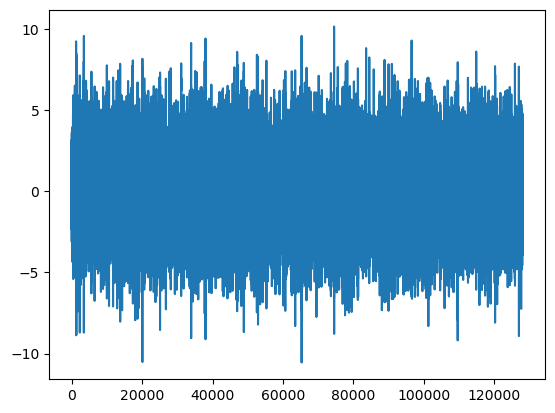

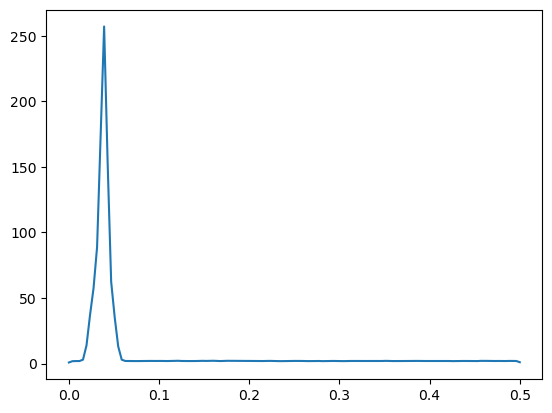

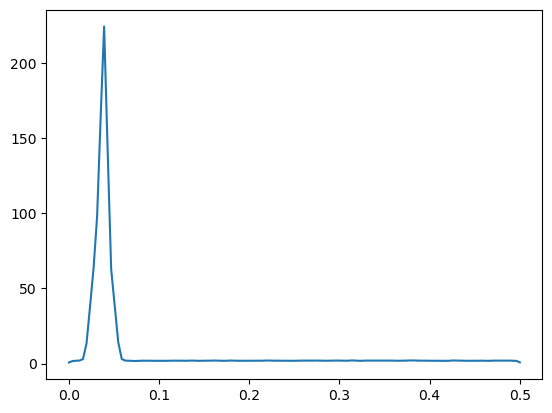

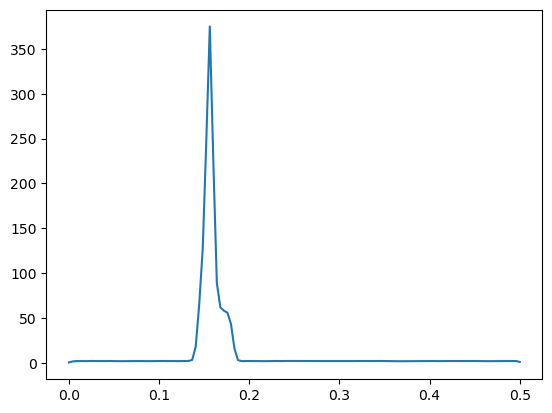

In [87]:
segment_length = 2**8
total_number_segments = 1000
psd_peak_strength = 10

# ------------------------------------

psd_1 = np.full((segment_length,), 1.0)
f1 = 10
mag_signal_f1 = psd_peak_strength
psd_1[f1-4:f1+4] = mag_signal_f1*5.0
psd_1[f1-2:f1+2] = mag_signal_f1*10.0
psd_1[f1] = mag_signal_f1*40.0
psd_1 = psd_1

signal_1 = generate_realization_from_PSD(psd=psd_1, segment_length=segment_length, n_overlap=segment_length//2, total_number_segments=total_number_segments)

plt.figure()
plt.plot(signal_1)
plt.show()

signal_1_welch_freq, signal_1_welch_psd = sp.signal.welch(signal_1, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=True)
plt.figure()
plt.plot(signal_1_welch_freq, signal_1_welch_psd)
plt.show()

# note that if you repeat, you get a similar but different PSD, as should be

signal_1 = generate_realization_from_PSD(psd=psd_1, segment_length=segment_length, n_overlap=segment_length//2, total_number_segments=total_number_segments)

signal_1_welch_freq, signal_1_welch_psd = sp.signal.welch(signal_1, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=True)
plt.figure()
plt.plot(signal_1_welch_freq, signal_1_welch_psd)
plt.show()

# ------------------------------------

psd_2 = np.full((segment_length,), 1.0)
f2 = 40
mag_signal_f2 = psd_peak_strength * 2
psd_2[f2-3:f2+7] = mag_signal_f2*3.0
psd_2[f2-2:f2+2] = mag_signal_f2*7.0
psd_2[f2] = mag_signal_f2*30.0
psd_2 = psd_2

signal_2 = generate_realization_from_PSD(psd=psd_2, segment_length=segment_length, n_overlap=segment_length//2, total_number_segments=total_number_segments)

if False:
    plt.figure()
    plt.plot(signal_2)
    plt.show()

signal_2_welch_freq, signal_2_welch_psd = sp.signal.welch(signal_2, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=True)
plt.figure()
plt.plot(signal_2_welch_freq, signal_2_welch_psd)
plt.show()

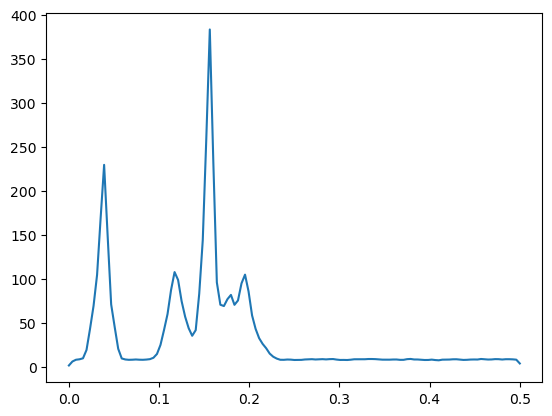

In [88]:
coupling_factor = 0.5
signal_3 = signal_1 + signal_2 + coupling_factor * signal_1 * signal_2

signal_3_welch_freq, signal_3_welch_psd = sp.signal.welch(signal_3, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=True)
plt.figure()
plt.plot(signal_3_welch_freq, signal_3_welch_psd)
plt.show()

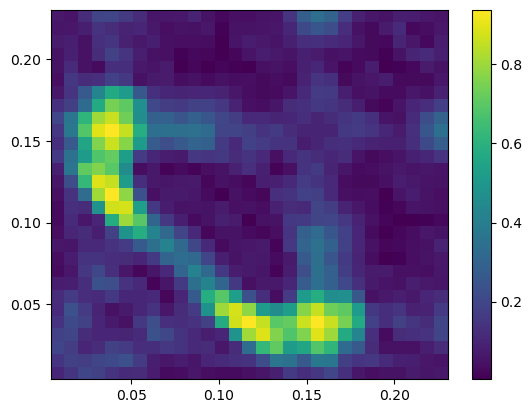

In [89]:
method = "absolute_norm"

f1_s3, f2_s3, ch_s3 = compute_auto_bicoherence(signal_3, sample_frequency=1.0, segment_length=segment_length//2, n_overlap=segment_length//4, f1_range=[0.0, 0.22], f2_range=[0.0, 0.22], method=method)

plt.figure()
plt.pcolormesh(f1_s3, f2_s3, np.transpose(ch_s3), shading='nearest')
plt.colorbar()
plt.show()

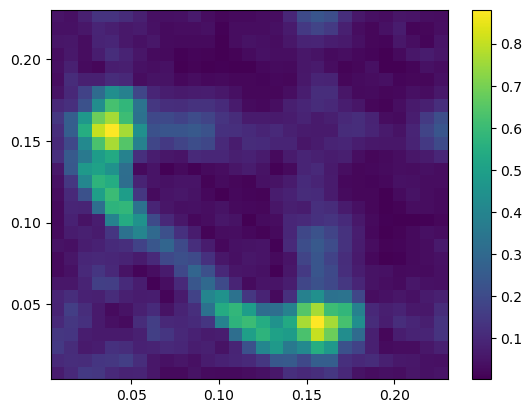

In [90]:
method = "square_norm"

f1_s3, f2_s3, ch_s3 = compute_auto_bicoherence(signal_3, sample_frequency=1.0, segment_length=segment_length//2, n_overlap=segment_length//4, f1_range=[0.0, 0.22], f2_range=[0.0, 0.22], method=method)

plt.figure()
plt.pcolormesh(f1_s3, f2_s3, np.transpose(ch_s3), shading='nearest')
plt.colorbar()
plt.show()

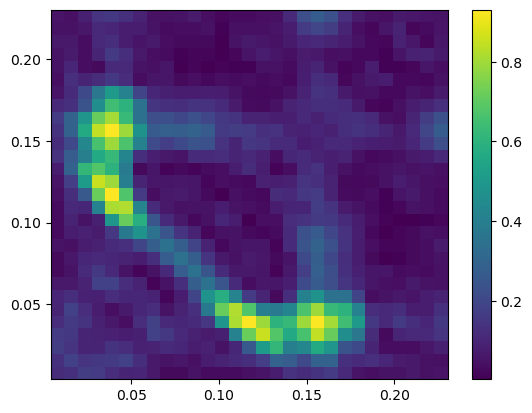

In [91]:
method = "square_norm_indep"

f1_s3, f2_s3, ch_s3 = compute_auto_bicoherence(signal_3, sample_frequency=1.0, segment_length=segment_length//2, n_overlap=segment_length//4, f1_range=[0.0, 0.22], f2_range=[0.0, 0.22], method=method)

plt.figure()
plt.pcolormesh(f1_s3, f2_s3, np.transpose(ch_s3), shading='nearest')
plt.colorbar()
plt.show()

In [92]:
from polycoherence import _plot_signal, polycoherence, plot_polycoherence

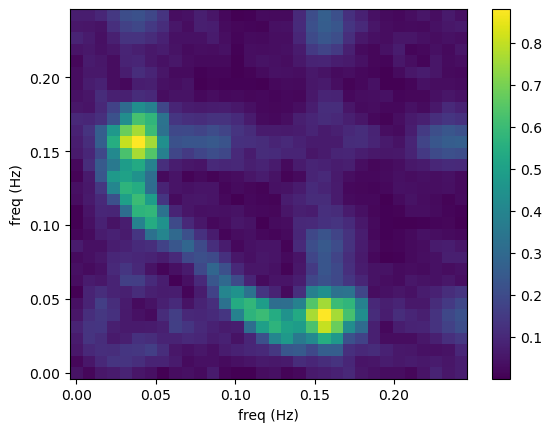

In [93]:
freq1, freq2, bispec = polycoherence(data=signal_3, fs=1.0, norm=2, window="hann", nperseg=segment_length//2, noverlap=segment_length//4, nfft=segment_length//2)
df1 = freq1[1] - freq1[0]
df2 = freq2[1] - freq2[0]
freq1 = np.append(freq1, freq1[-1] + df1) - 0.5 * df1
freq2 = np.append(freq2, freq2[-1] + df2) - 0.5 * df2

plt.figure()
plt.pcolormesh(freq2, freq1, np.abs(bispec))
plt.xlabel('freq (Hz)')
plt.ylabel('freq (Hz)')
plt.colorbar()


### S3'

$S3'$ has nearly the same PSD (difference is rounding, stochasticity, etc) as $S3$, but a very different bicoherence: no peak whatsoever in the bicoherence, since the secondary peaks do not correspond to nonlinear terms, only to independant components.

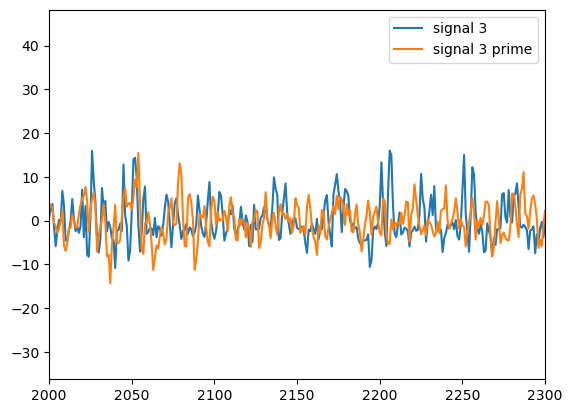

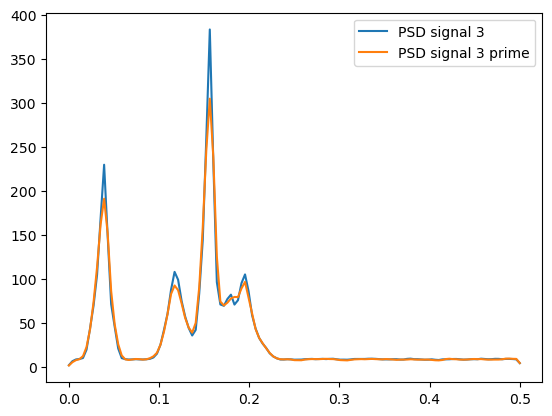

In [96]:
_, signal_3_welch_psd_2sided = sp.signal.welch(signal_3, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=False)
signal_3prime = generate_realization_from_PSD(psd=signal_3_welch_psd_2sided, segment_length=segment_length, n_overlap=segment_length//2, total_number_segments=total_number_segments)

plt.figure()
plt.plot(signal_3, label="signal 3")
plt.plot(signal_3prime, label="signal 3 prime")
start=2000
length=300
plt.xlim([start,start+length])
plt.legend()
plt.show()

signal_3prime_welch_freq, signal_3prime_welch_psd = sp.signal.welch(signal_3prime, 1.0, nperseg=segment_length, noverlap=segment_length//2, scaling='density', return_onesided=True)
plt.figure()
plt.plot(signal_3_welch_freq, signal_3_welch_psd, label="PSD signal 3")
plt.plot(signal_3prime_welch_freq, signal_3prime_welch_psd, label="PSD signal 3 prime")
plt.legend()
plt.show()

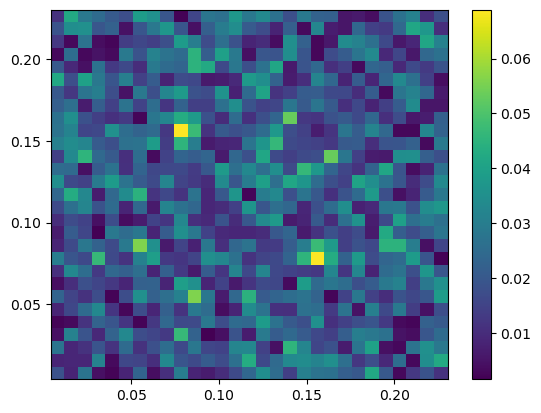

In [97]:
method = "square_norm"

f1_s3prime, f2_s3prime, ch_s3prime = compute_auto_bicoherence(signal_3prime, sample_frequency=1.0, segment_length=segment_length//2, n_overlap=segment_length//4, f1_range=[0.0, 0.22], f2_range=[0.0, 0.22], method=method)

plt.figure()
plt.pcolormesh(f1_s3prime, f2_s3prime, np.transpose(ch_s3prime), shading='nearest')
plt.colorbar()
plt.show()